## 0. Environment Setup
Post-pipeline audit: validate processed splits before model training.
Loads parquet outputs from training pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
import shap
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

from pathlib import Path

ROOT        = Path(r"C:\Users\sharg\Desktop\github\DriftSentinel")
FIGURE_DIR  = ROOT / "outputs" / "figure"
ARTIFACT_DIR= ROOT / "outputs" / "artifacts"
LOG_DIR     = ROOT / "outputs" / "log"
TRAIN_DIR   = ROOT / "data" / "train"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print(f"Figures -> {FIGURE_DIR}")

Setup complete
Figures -> C:\Users\sharg\Desktop\github\DriftSentinel\outputs\figure


## 1. Load Processed Splits
Parquet files output from training pipeline Stage 8.
53 selected features + 2 target columns per split.

In [2]:
train = pd.read_parquet(TRAIN_DIR / "train_fs.parquet")
val   = pd.read_parquet(TRAIN_DIR / "val_fs.parquet")
test  = pd.read_parquet(TRAIN_DIR / "test_fs.parquet")

TARGET_COLS  = ["readmitted_binary", "readmitted_multi"]
FEAT_COLS    = [c for c in train.columns if c not in TARGET_COLS]
FE_COLS      = [c for c in FEAT_COLS if c.startswith("FE_")]
RAW_COLS     = [c for c in FEAT_COLS if not c.startswith("FE_")]

print(f"Train : {train.shape}")
print(f"Val   : {val.shape}")
print(f"Test  : {test.shape}")
print(f"\nFeature columns  : {len(FEAT_COLS)}")
print(f"  FE_ engineered : {len(FE_COLS)}")
print(f"  Raw features   : {len(RAW_COLS)}")
print(f"\nTarget columns   : {TARGET_COLS}")
print(f"\nFE_ features:")
for f in FE_COLS:
    print(f"  {f}")

Train : (63492, 55)
Val   : (20949, 55)
Test  : (17325, 55)

Feature columns  : 53
  FE_ engineered : 29
  Raw features   : 24

Target columns   : ['readmitted_binary', 'readmitted_multi']

FE_ features:
  FE_total_clinical_contacts
  FE_labs_per_day
  FE_meds_per_day
  FE_high_utilization
  FE_n_active_binary_meds
  FE_total_active_meds
  FE_n_med_increases
  FE_n_med_decreases
  FE_any_med_changed
  FE_diagnoses_per_day
  FE_diag_med_ratio
  FE_high_lab_load
  FE_no_procedures
  FE_lab_to_procedure_ratio
  FE_has_prior_inpatient
  FE_high_prior_utilization
  FE_multi_channel_utilizer
  FE_insulin_prescribed
  FE_insulin_changed
  FE_insulin_increased
  FE_metformin_prescribed
  FE_metformin_changed
  FE_on_diabetes_med
  FE_med_regimen_changed
  FE_glycemic_risk_score
  FE_high_util_x_med_change
  FE_comorbidity_x_lab_load
  FE_glycemic_x_emergency
  FE_labs_per_day_x_comorbidity


## 2. Split Summary & Target Distribution
Confirms row counts, leakage-free patient split, and target class balance across windows.
Test window shows concept drift — NO rate rises from 51% to 66.4%.

SPLIT SUMMARY

TRAIN (63,492 rows / 62.4%)
  binary: NO=51.0%  readmit=49.0%
  multi : NO=51.0%  <30=12.0%  >30=37.0%

VAL (20,949 rows / 20.6%)
  binary: NO=52.4%  readmit=47.6%
  multi : NO=52.4%  <30=10.6%  >30=37.1%

TEST (17,325 rows / 17.0%)
  binary: NO=66.4%  readmit=33.6%
  multi : NO=66.4%  <30=8.8%  >30=24.8%


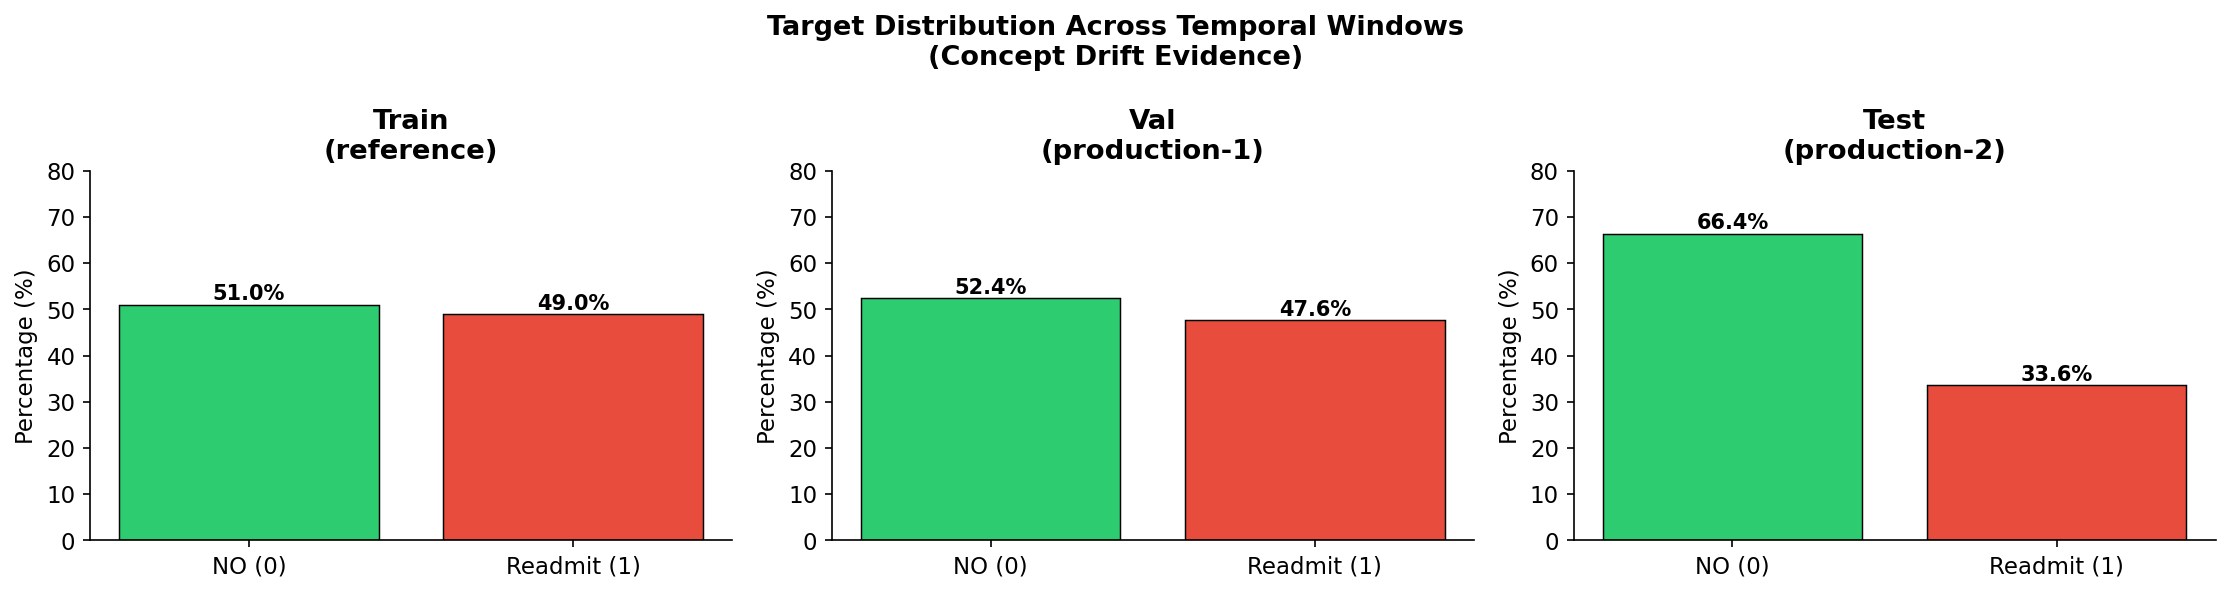

Saved: 13_target_temporal_shift.png


In [3]:
print("=" * 60)
print("SPLIT SUMMARY")
print("=" * 60)

total = len(train) + len(val) + len(test)
for name, df in [("train", train), ("val", val), ("test", test)]:
    binary = df["readmitted_binary"].value_counts(normalize=True)*100
    multi  = df["readmitted_multi"].value_counts(normalize=True)*100
    print(f"\n{name.upper()} ({len(df):,} rows / {len(df)/total*100:.1f}%)")
    print(f"  binary: NO={binary.get(0,0):.1f}%  readmit={binary.get(1,0):.1f}%")
    print(f"  multi : NO={multi.get(0,0):.1f}%  <30={multi.get(1,0):.1f}%  >30={multi.get(2,0):.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#2ecc71','#e74c3c']
labels = ['NO (0)', 'Readmit (1)']

for ax, (name, df) in zip(axes, [("Train\n(reference)", train),
                                   ("Val\n(production-1)", val),
                                   ("Test\n(production-2)", test)]):
    dist = df["readmitted_binary"].value_counts(normalize=True)*100
    bars = ax.bar(labels, [dist.get(0,0), dist.get(1,0)],
                  color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, 80)
    for bar, val_ in zip(bars, [dist.get(0,0), dist.get(1,0)]):
        ax.text(bar.get_x() + bar.get_width()/2, val_+1,
                f'{val_:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Target Distribution Across Temporal Windows\n(Concept Drift Evidence)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / "13_target_temporal_shift.png", bbox_inches='tight')
plt.show()
print("Saved: 13_target_temporal_shift.png")

## 3. Data Leakage Audit
Three-layer leakage verification:
    Layer 1 — Row-level: no identical rows across splits
    Layer 2 — Feature-target correlation: no feature |r| > 0.80 with target
    Layer 3 — Near-duplicate detection: pairwise hash comparison

In [4]:
print("=" * 60)
print("DATA LEAKAGE AUDIT")
print("=" * 60)

# Layer 1: Row-level hash
print("\nLayer 1: Row-level duplicate detection")
train_hashes = set(pd.util.hash_pandas_object(train[FEAT_COLS], index=False).values)
for name, df in [("val", val), ("test", test)]:
    split_hashes = pd.util.hash_pandas_object(df[FEAT_COLS], index=False).values
    leaked = sum(1 for h in split_hashes if h in train_hashes)
    pct    = leaked / len(df) * 100
    status = "PASS" if leaked == 0 else "FAIL"
    print(f"  [{status}] train ∩ {name} : {leaked:,} duplicate rows ({pct:.4f}%)")

# Layer 2: Feature-target correlation
print("\nLayer 2: Feature-target Pearson correlation (threshold |r| > 0.80)")
suspicious = []
for feat in FEAT_COLS:
    for tgt in TARGET_COLS:
        r = train[feat].corr(train[tgt])
        if abs(r) > 0.80:
            suspicious.append((feat, tgt, round(r, 4)))

if suspicious:
    print(f"  [FAIL] {len(suspicious)} suspicious pairs:")
    for f, t, r in suspicious:
        print(f"    {f} vs {t}: r={r}")
else:
    print(f"  [PASS] No |r| > 0.80 among {len(FEAT_COLS)} features × {len(TARGET_COLS)} targets")

# Layer 3: Correlation matrix of features only — identify internal leakage
print("\nLayer 3: High inter-feature correlation (|r| > 0.95)")
corr_matrix = train[FEAT_COLS].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_pairs = [(col, row, round(upper.loc[row, col], 4))
              for col in upper.columns
              for row in upper.index
              if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.95]

if high_pairs:
    print(f"  [WARN] {len(high_pairs)} feature pairs with |r| > 0.95:")
    for a, b, r in sorted(high_pairs, key=lambda x: -x[2])[:10]:
        print(f"    {a} vs {b}: r={r}")
else:
    print(f"  [PASS] No feature pairs with |r| > 0.95")

print("\nLeakage audit complete")

DATA LEAKAGE AUDIT

Layer 1: Row-level duplicate detection
  [PASS] train ∩ val : 0 duplicate rows (0.0000%)
  [PASS] train ∩ test : 0 duplicate rows (0.0000%)

Layer 2: Feature-target Pearson correlation (threshold |r| > 0.80)
  [PASS] No |r| > 0.80 among 53 features × 2 targets

Layer 3: High inter-feature correlation (|r| > 0.95)
  [PASS] No feature pairs with |r| > 0.95

Leakage audit complete


## 4. PSI Distribution Shift Heatmap
Population Stability Index per feature across val and test windows.
PSI > 0.20 = critical drift. PSI 0.10-0.20 = moderate. PSI < 0.10 = stable.
These are the exact drift signals DriftSentinel will monitor in production.

=== PSI Summary ===
Critical (>0.20) : 5 features
Moderate (0.10-0.20): 2 features
Stable   (<0.10) : 46 features

Top 15 drifted features:
                      feature  psi_val  psi_test  max_psi  is_fe
                   payer_code   0.9309    0.8402   0.9309  False
            medical_specialty   0.3278    0.4430   0.4430  False
          admission_source_id   0.2909    0.2027   0.2909  False
             number_diagnoses   0.1681    0.2588   0.2588  False
FE_labs_per_day_x_comorbidity   0.1530    0.2146   0.2146   True
            admission_type_id   0.0671    0.1904   0.1904  False
         FE_diagnoses_per_day   0.0717    0.1342   0.1342   True
              FE_meds_per_day   0.0465    0.0750   0.0750   True
     discharge_disposition_id   0.0555    0.0643   0.0643  False
                         race   0.0337    0.0513   0.0513  False
    FE_lab_to_procedure_ratio   0.0216    0.0512   0.0512   True
            number_outpatient   0.0450    0.0048   0.0450  False
   FE_total_cli

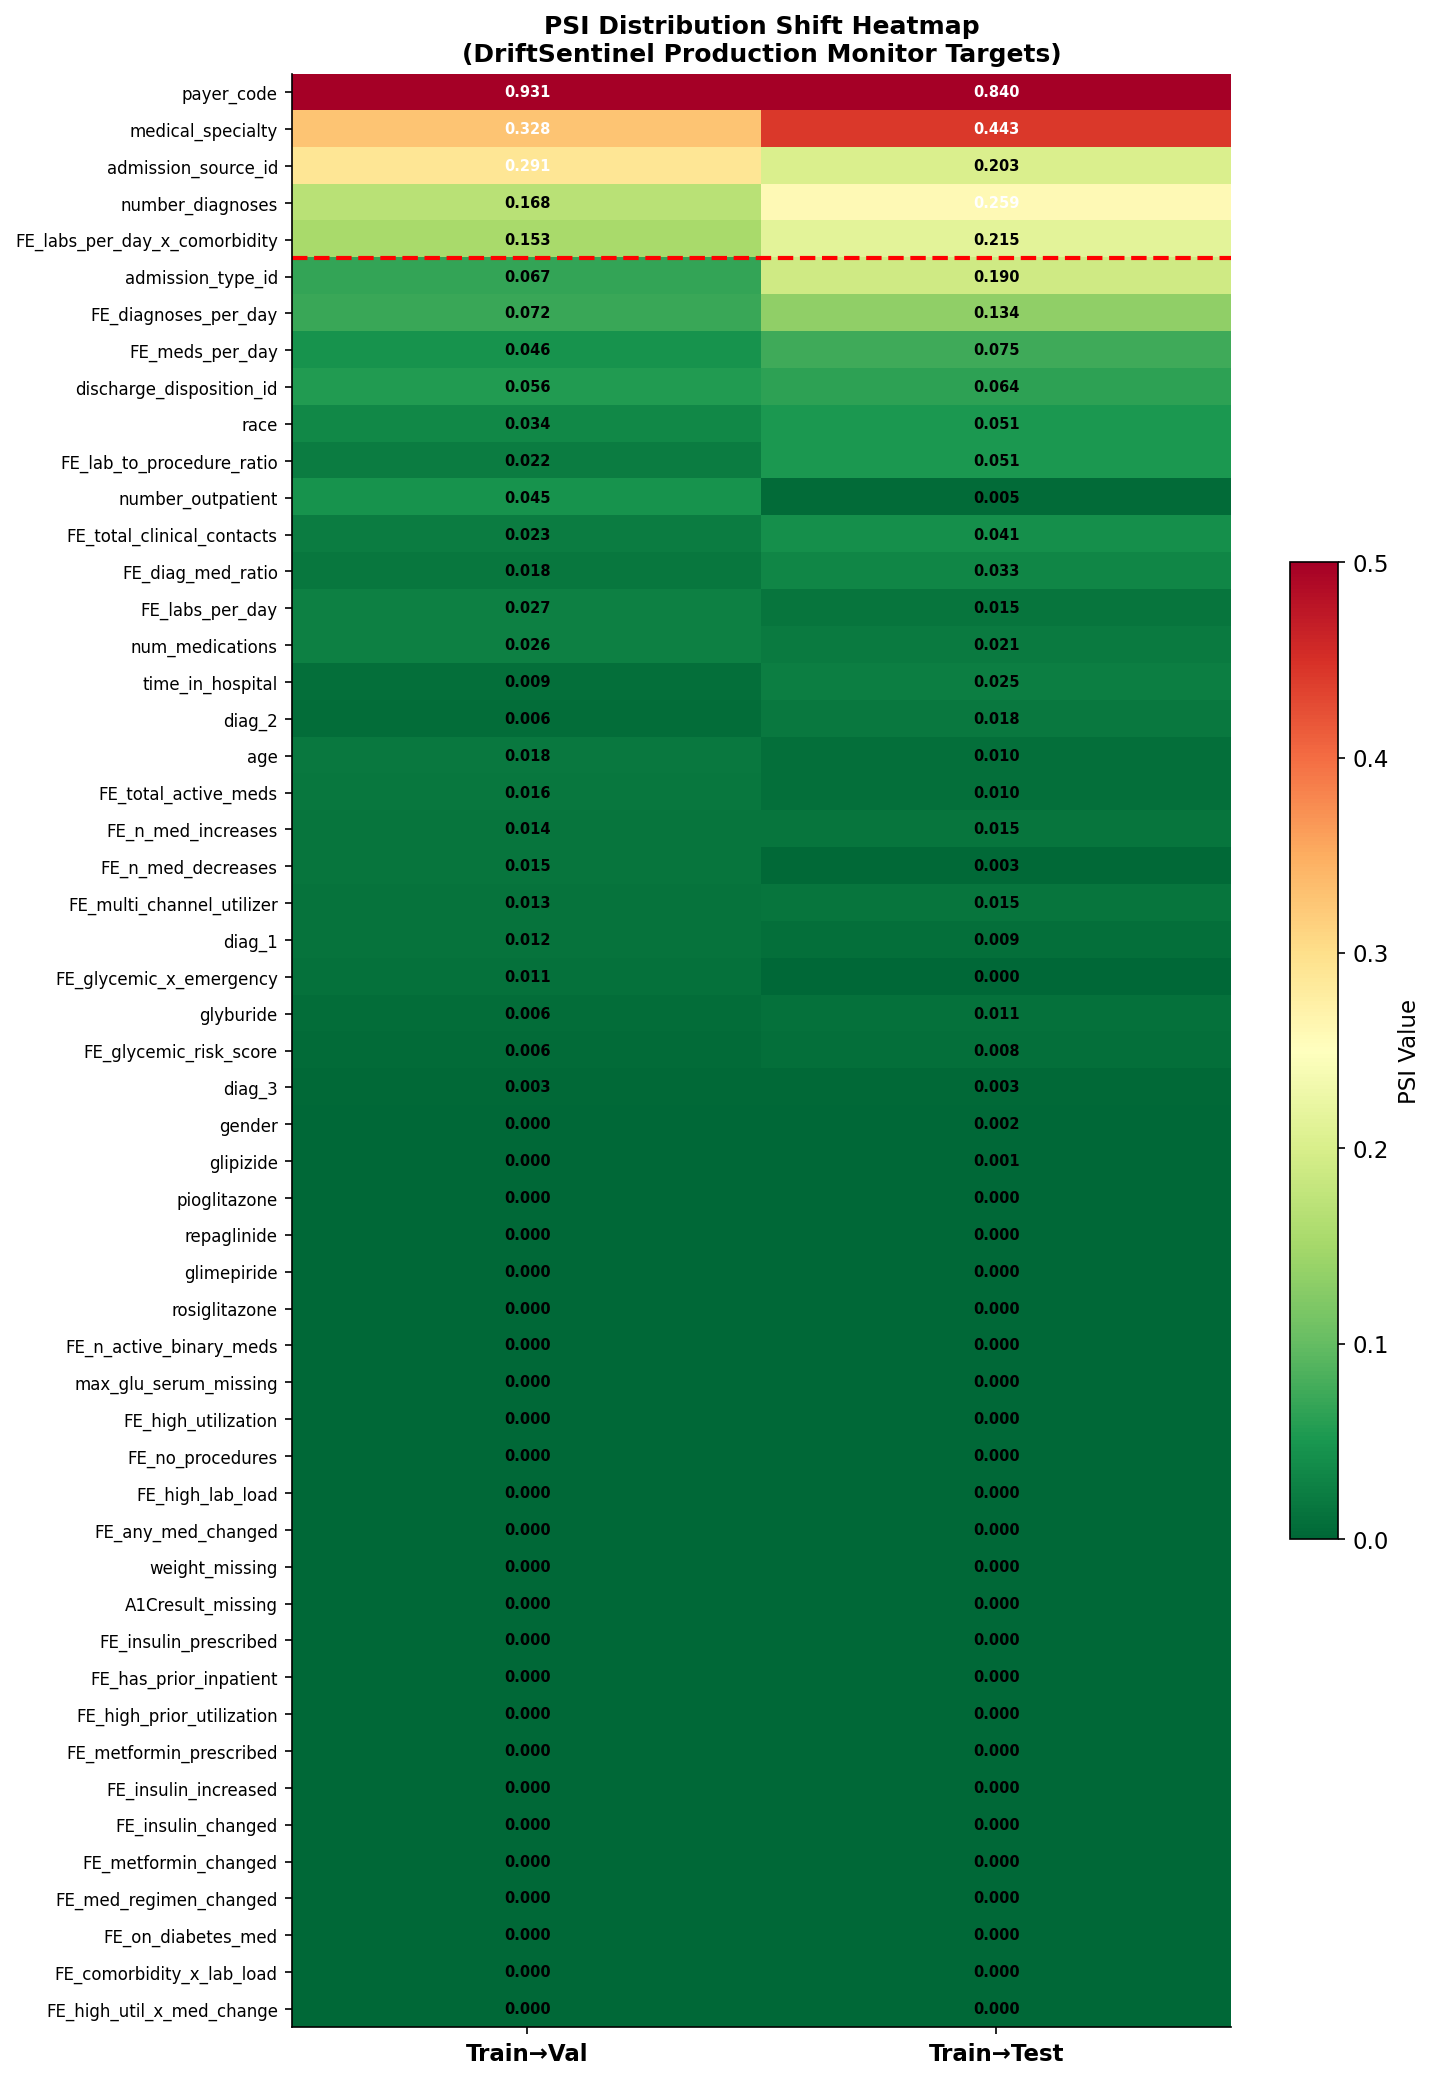

Saved: 14_psi_drift_heatmap.png


In [5]:
def psi(ref, prod, n_bins=10):
    ref  = ref[~np.isnan(ref)]
    prod = prod[~np.isnan(prod)]
    if len(ref) == 0 or len(prod) == 0:
        return np.nan
    bp = np.unique(np.percentile(ref, np.linspace(0, 100, n_bins+1)))
    if len(bp) < 2:
        return np.nan
    r_pct = np.histogram(ref,  bins=bp)[0] / len(ref)  + 1e-8
    p_pct = np.histogram(prod, bins=bp)[0] / len(prod) + 1e-8
    return float(np.sum((p_pct - r_pct) * np.log(p_pct / r_pct)))

psi_records = []
for feat in FEAT_COLS:
    psi_val  = psi(train[feat].values, val[feat].values)
    psi_test = psi(train[feat].values, test[feat].values)
    psi_records.append({
        "feature" : feat,
        "psi_val" : round(psi_val,  4),
        "psi_test": round(psi_test, 4),
        "max_psi" : round(max(psi_val, psi_test), 4),
        "is_fe"   : feat.startswith("FE_")
    })

psi_df = pd.DataFrame(psi_records).sort_values("max_psi", ascending=False)

print("=== PSI Summary ===")
print(f"Critical (>0.20) : {(psi_df['max_psi'] > 0.20).sum()} features")
print(f"Moderate (0.10-0.20): {((psi_df['max_psi'] > 0.10) & (psi_df['max_psi'] <= 0.20)).sum()} features")
print(f"Stable   (<0.10) : {(psi_df['max_psi'] < 0.10).sum()} features")
print(f"\nTop 15 drifted features:")
print(psi_df.head(15).to_string(index=False))

# Heatmap
fig, ax = plt.subplots(figsize=(10, 14))
heatmap_data = psi_df.set_index("feature")[["psi_val", "psi_test"]]
heatmap_data.columns = ["Train→Val", "Train→Test"]

cmap = plt.cm.RdYlGn_r
im = ax.imshow(heatmap_data.values, cmap=cmap, aspect='auto', vmin=0, vmax=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Train→Val", "Train→Test"], fontsize=11, fontweight='bold')
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=8)

for i in range(len(heatmap_data)):
    for j in range(2):
        val_ = heatmap_data.values[i, j]
        color = 'white' if val_ > 0.25 else 'black'
        ax.text(j, i, f'{val_:.3f}', ha='center', va='center',
                fontsize=7, color=color, fontweight='bold')

ax.axhline(y=(psi_df['max_psi'] > 0.20).sum() - 0.5,
           color='red', linewidth=2, linestyle='--', label='PSI=0.20 boundary')
plt.colorbar(im, ax=ax, label='PSI Value', shrink=0.5)
ax.set_title('PSI Distribution Shift Heatmap\n(DriftSentinel Production Monitor Targets)',
             fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "14_psi_drift_heatmap.png", bbox_inches='tight')
plt.show()
print("Saved: 14_psi_drift_heatmap.png")

## 5. Mutual Information Scores
Non-linear relevance of each feature with binary readmission target.
Computed on train split only. Top features guide model architecture choice.

=== Mutual Information — Top 20 ===
                      feature  mi_score  is_fe
    FE_multi_channel_utilizer    0.0295   True
       FE_has_prior_inpatient    0.0286   True
    FE_high_prior_utilization    0.0262   True
          admission_source_id    0.0165  False
     discharge_disposition_id    0.0163  False
             number_diagnoses    0.0156  False
            FE_diag_med_ratio    0.0141   True
            medical_specialty    0.0116  False
      FE_glycemic_x_emergency    0.0107   True
            number_outpatient    0.0095  False
            A1Cresult_missing    0.0090  False
FE_labs_per_day_x_comorbidity    0.0087   True
         FE_diagnoses_per_day    0.0086   True
        FE_insulin_prescribed    0.0086   True
       FE_med_regimen_changed    0.0071   True
        max_glu_serum_missing    0.0069  False
               weight_missing    0.0069  False
             FE_no_procedures    0.0067   True
                       diag_2    0.0056  False
                       d

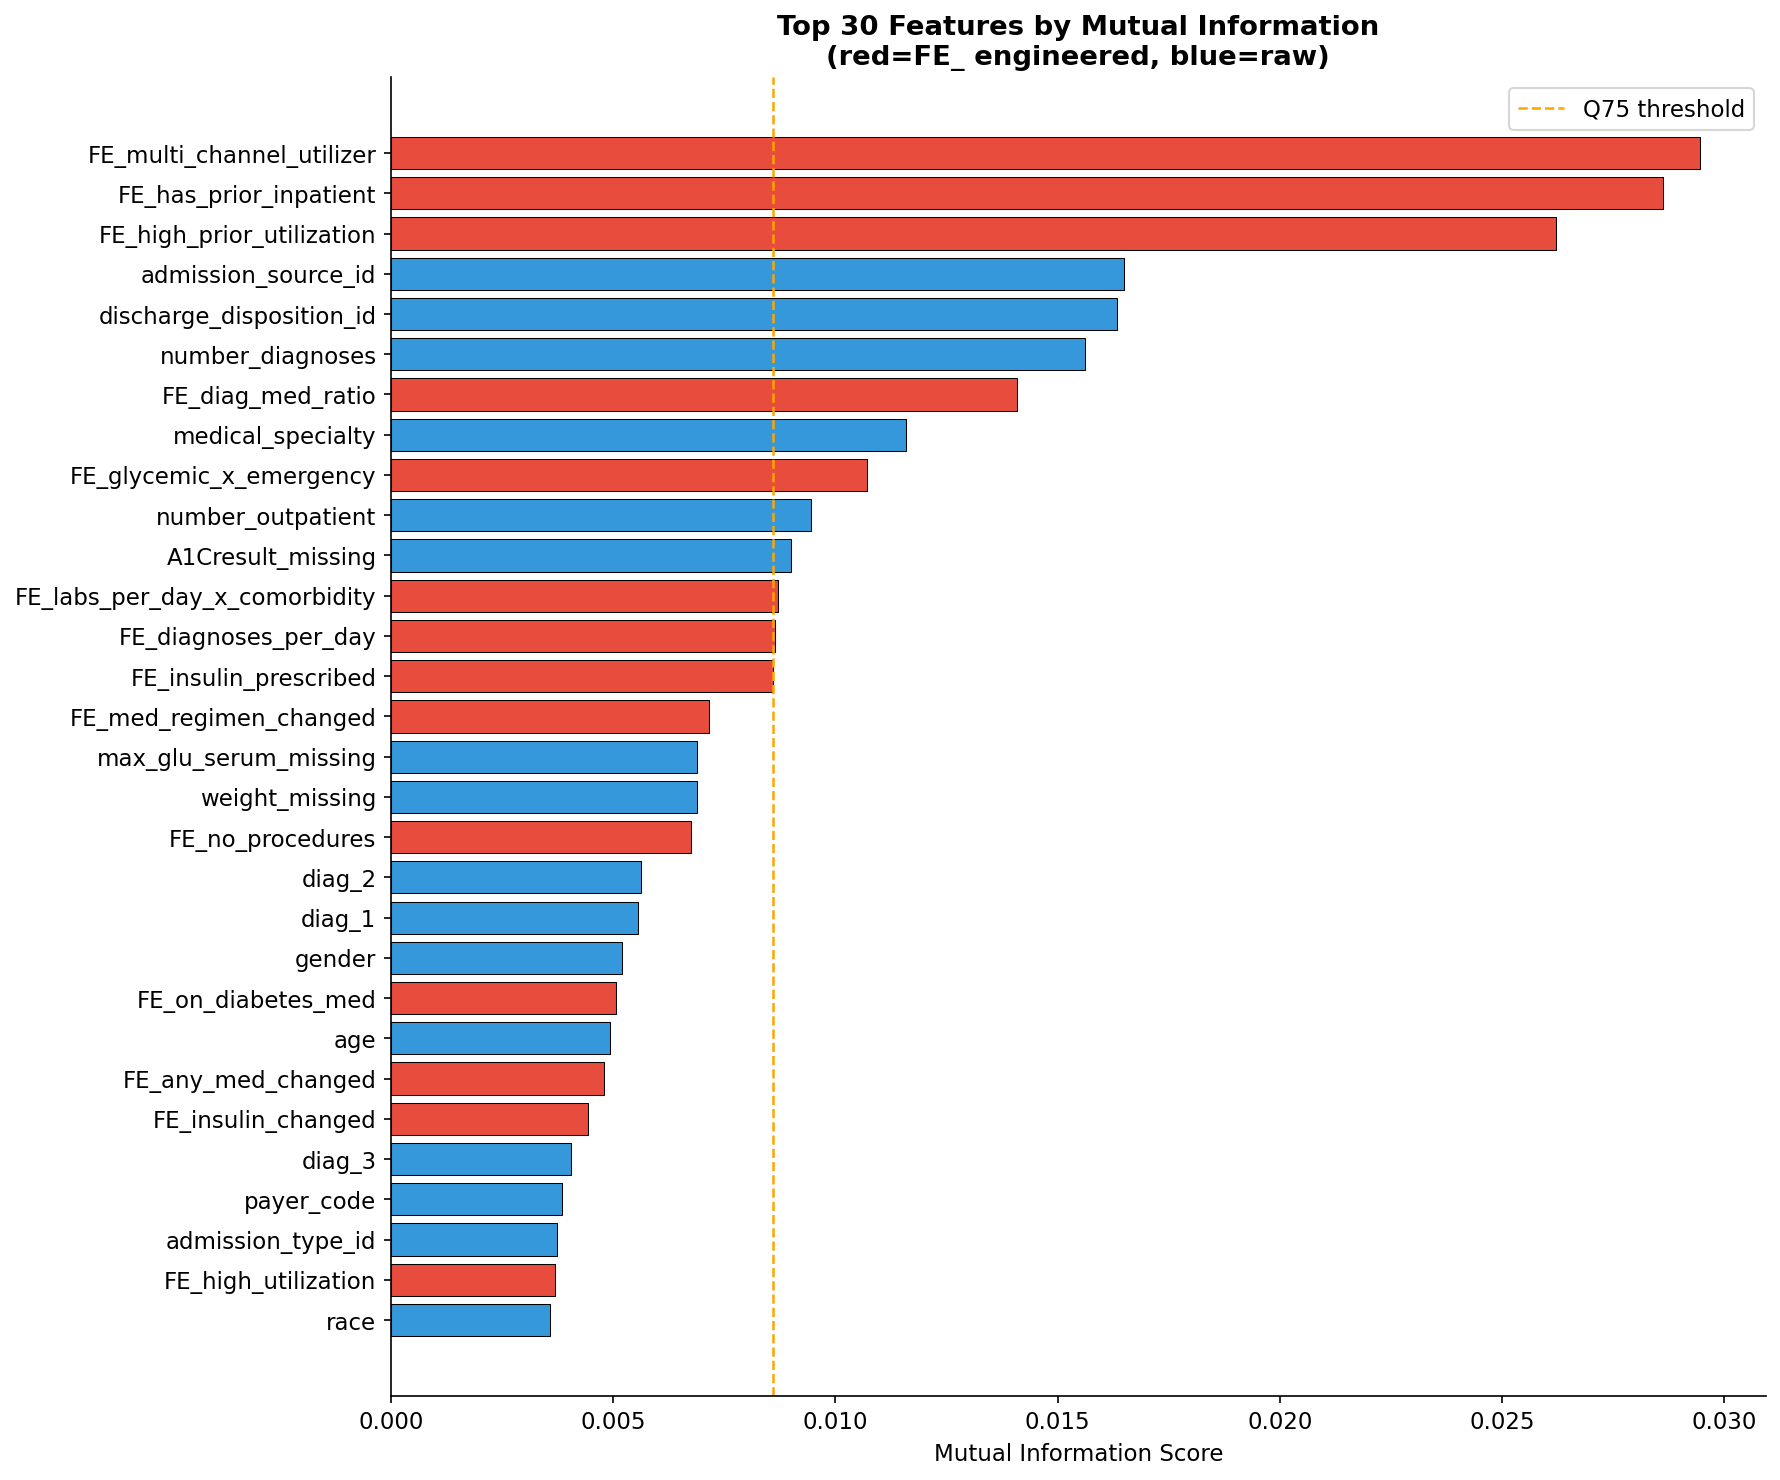

Saved: 15_mutual_information_scores.png


In [6]:
from sklearn.feature_selection import mutual_info_classif

X_train = train[FEAT_COLS].fillna(0)
y_train = train["readmitted_binary"]

mi_scores = mutual_info_classif(X_train, y_train,
                                 discrete_features="auto",
                                 random_state=42)
mi_df = pd.DataFrame({
    "feature"  : FEAT_COLS,
    "mi_score" : mi_scores,
    "is_fe"    : [f.startswith("FE_") for f in FEAT_COLS]
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

print("=== Mutual Information — Top 20 ===")
print(mi_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 10))
top_n = 30
plot_df = mi_df.head(top_n)
colors  = ['#e74c3c' if fe else '#3498db' for fe in plot_df['is_fe']]
bars = ax.barh(plot_df['feature'][::-1], plot_df['mi_score'][::-1],
               color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mutual Information Score')
ax.set_title(f'Top {top_n} Features by Mutual Information\n(red=FE_ engineered, blue=raw)',
             fontweight='bold')
ax.axvline(mi_df['mi_score'].quantile(0.75), color='orange',
           linestyle='--', linewidth=1.2, label='Q75 threshold')
ax.legend()

# FE vs raw breakdown
fe_top10  = mi_df[mi_df['is_fe']].head(10)
raw_top10 = mi_df[~mi_df['is_fe']].head(10)
print(f"\nFE_ features in top 20: {(mi_df.head(20)['is_fe']).sum()}")
print(f"Raw features in top 20: {(~mi_df.head(20)['is_fe']).sum()}")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "15_mutual_information_scores.png", bbox_inches='tight')
plt.show()
print("Saved: 15_mutual_information_scores.png")

## 6. SHAP Feature Importance
Model-based importance via TreeExplainer on RandomForest trained on train split.
Mean |SHAP| ranks features by actual contribution to predictions.
Most faithful importance metric — unbiased for high-cardinality features.

Training RF for SHAP analysis (train split only)...
SHAP values shape used: (63492, 53)
Features expected     : 53

=== SHAP Importance — Top 20 ===
                      feature  shap_mean  is_fe
    FE_multi_channel_utilizer     0.0434   True
       FE_has_prior_inpatient     0.0323   True
    FE_high_prior_utilization     0.0280   True
             number_diagnoses     0.0215  False
          admission_source_id     0.0140  False
     discharge_disposition_id     0.0139  False
FE_labs_per_day_x_comorbidity     0.0133   True
      FE_glycemic_x_emergency     0.0081   True
              num_medications     0.0068  False
            number_outpatient     0.0060  False
         FE_total_active_meds     0.0049   True
           FE_insulin_changed     0.0047   True
            medical_specialty     0.0044  False
                          age     0.0043  False
           FE_on_diabetes_med     0.0037   True
            FE_diag_med_ratio     0.0036   True
    FE_lab_to_procedure_ratio     0

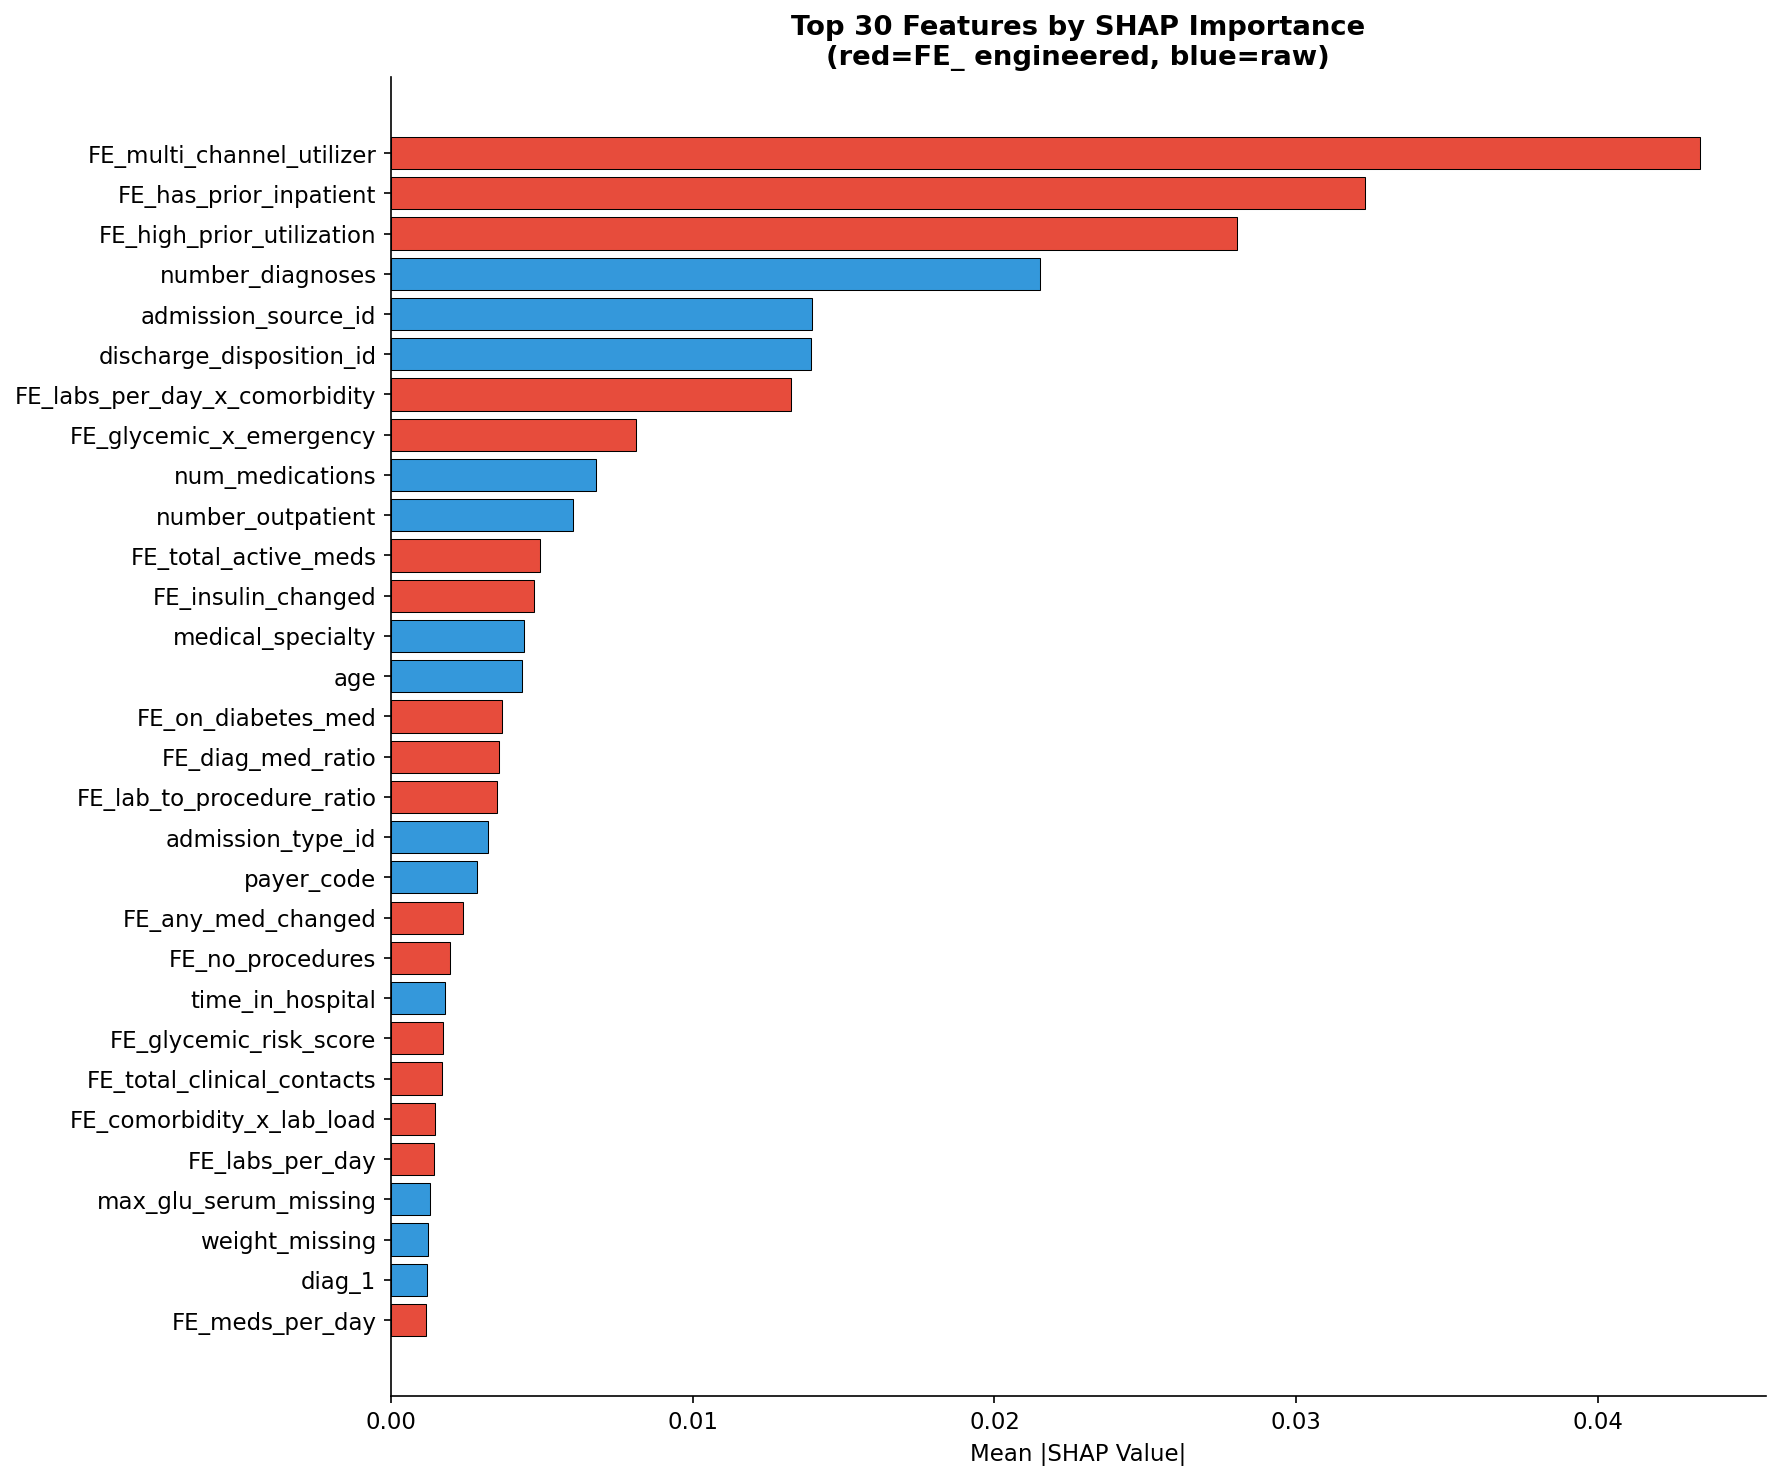

Saved: 16_shap_importance.png


In [8]:
print("Training RF for SHAP analysis (train split only)...")
X_tr = train[FEAT_COLS].fillna(0).values
y_tr = train["readmitted_binary"].values

rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             n_jobs=-1, random_state=42)
rf.fit(X_tr, y_tr)

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_tr)

# Handle all SHAP output shapes
if isinstance(shap_values, list):
    # list of arrays: [class0_array, class1_array]
    sv = shap_values[1]
elif shap_values.ndim == 3:
    # 3D array: (n_samples, n_features, n_classes) — take class 1
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

# Ensure 2D: (n_samples, n_features)
if sv.ndim != 2:
    sv = np.array(sv)
    if sv.ndim == 3:
        sv = sv[:, :, 1]

print(f"SHAP values shape used: {sv.shape}")
print(f"Features expected     : {len(FEAT_COLS)}")

mean_shap = pd.DataFrame({
    "feature"  : FEAT_COLS,
    "shap_mean": np.abs(sv).mean(axis=0),
    "is_fe"    : [f.startswith("FE_") for f in FEAT_COLS]
}).sort_values("shap_mean", ascending=False).reset_index(drop=True)

print("\n=== SHAP Importance — Top 20 ===")
print(mean_shap.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 10))
top_n   = 30
plot_df = mean_shap.head(top_n)
colors  = ['#e74c3c' if fe else '#3498db' for fe in plot_df['is_fe']]
ax.barh(plot_df['feature'][::-1], plot_df['shap_mean'][::-1],
        color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title(f'Top {top_n} Features by SHAP Importance\n(red=FE_ engineered, blue=raw)',
             fontweight='bold')

fe_top = (mean_shap.head(20)['is_fe']).sum()
print(f"\nFE_ features in SHAP top 20: {fe_top}")
print(f"Raw features in SHAP top 20: {20 - fe_top}")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "16_shap_importance.png", bbox_inches='tight')
plt.show()
print("Saved: 16_shap_importance.png")

## 7. MI vs SHAP Rank Correlation
Spearman correlation between MI and SHAP rankings.
High correlation confirms both metrics agree on feature importance.
Divergence highlights features with non-linear signal (MI) vs model contribution (SHAP).

Spearman rank correlation (MI vs SHAP): rho=0.6537  p=1.1170e-07
Interpretation: Moderate agreement


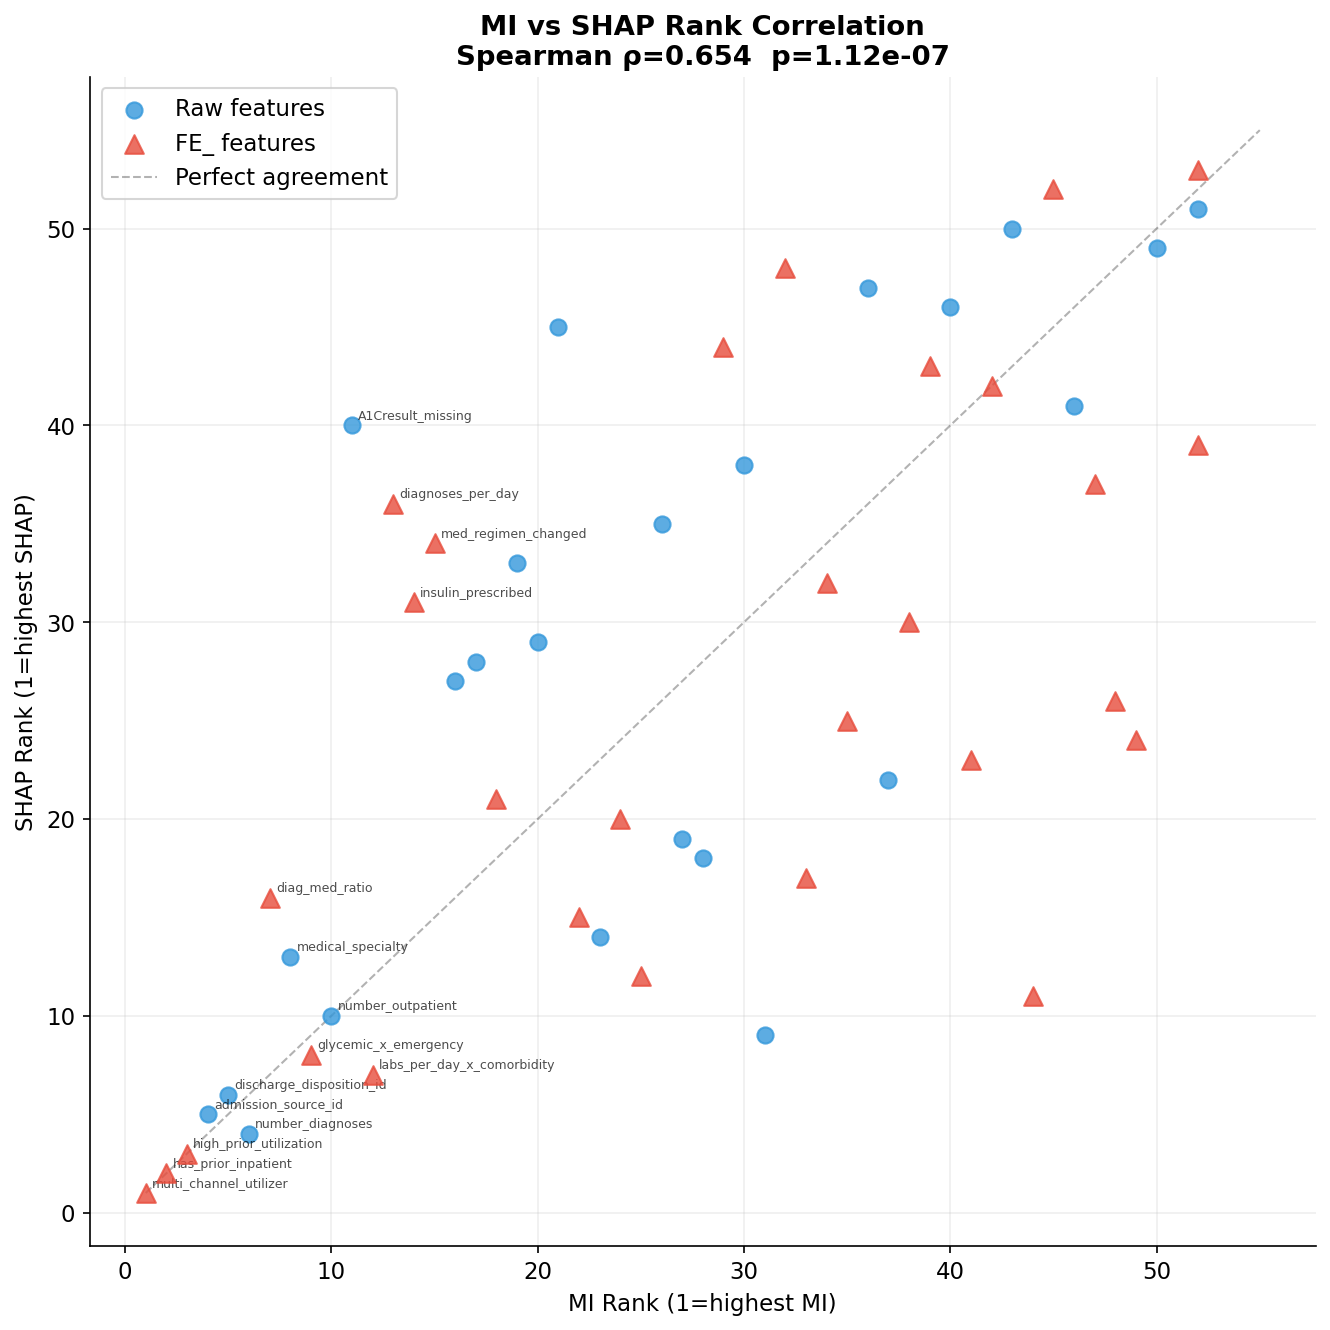

Saved: 17_mi_vs_shap_rank.png


In [9]:
from scipy.stats import spearmanr

merged = mi_df.merge(mean_shap, on=["feature", "is_fe"])
merged["mi_rank"]   = merged["mi_score"].rank(ascending=False)
merged["shap_rank"] = merged["shap_mean"].rank(ascending=False)

rho, p = spearmanr(merged["mi_rank"], merged["shap_rank"])
print(f"Spearman rank correlation (MI vs SHAP): rho={rho:.4f}  p={p:.4e}")
print(f"Interpretation: {'Strong agreement' if rho > 0.7 else 'Moderate agreement' if rho > 0.5 else 'Weak agreement'}")

fig, ax = plt.subplots(figsize=(9, 9))
fe_mask = merged["is_fe"]
ax.scatter(merged.loc[~fe_mask, "mi_rank"],
           merged.loc[~fe_mask, "shap_rank"],
           c='#3498db', alpha=0.8, s=60, label='Raw features', zorder=3)
ax.scatter(merged.loc[fe_mask, "mi_rank"],
           merged.loc[fe_mask, "shap_rank"],
           c='#e74c3c', alpha=0.8, s=80, marker='^', label='FE_ features', zorder=4)

for _, row in merged.head(15).iterrows():
    ax.annotate(row["feature"].replace("FE_", ""),
                (row["mi_rank"], row["shap_rank"]),
                fontsize=6, alpha=0.7,
                xytext=(3, 3), textcoords='offset points')

lim = max(merged["mi_rank"].max(), merged["shap_rank"].max()) + 2
ax.plot([1, lim], [1, lim], 'k--', alpha=0.3, linewidth=1, label='Perfect agreement')
ax.set_xlabel('MI Rank (1=highest MI)')
ax.set_ylabel('SHAP Rank (1=highest SHAP)')
ax.set_title(f'MI vs SHAP Rank Correlation\nSpearman ρ={rho:.3f}  p={p:.2e}',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "17_mi_vs_shap_rank.png", bbox_inches='tight')
plt.show()
print("Saved: 17_mi_vs_shap_rank.png")

## 8. Top Feature Distributions Across Splits
Distribution comparison of top 12 features by SHAP importance.
Visual confirmation of stable vs drifted features before modeling.

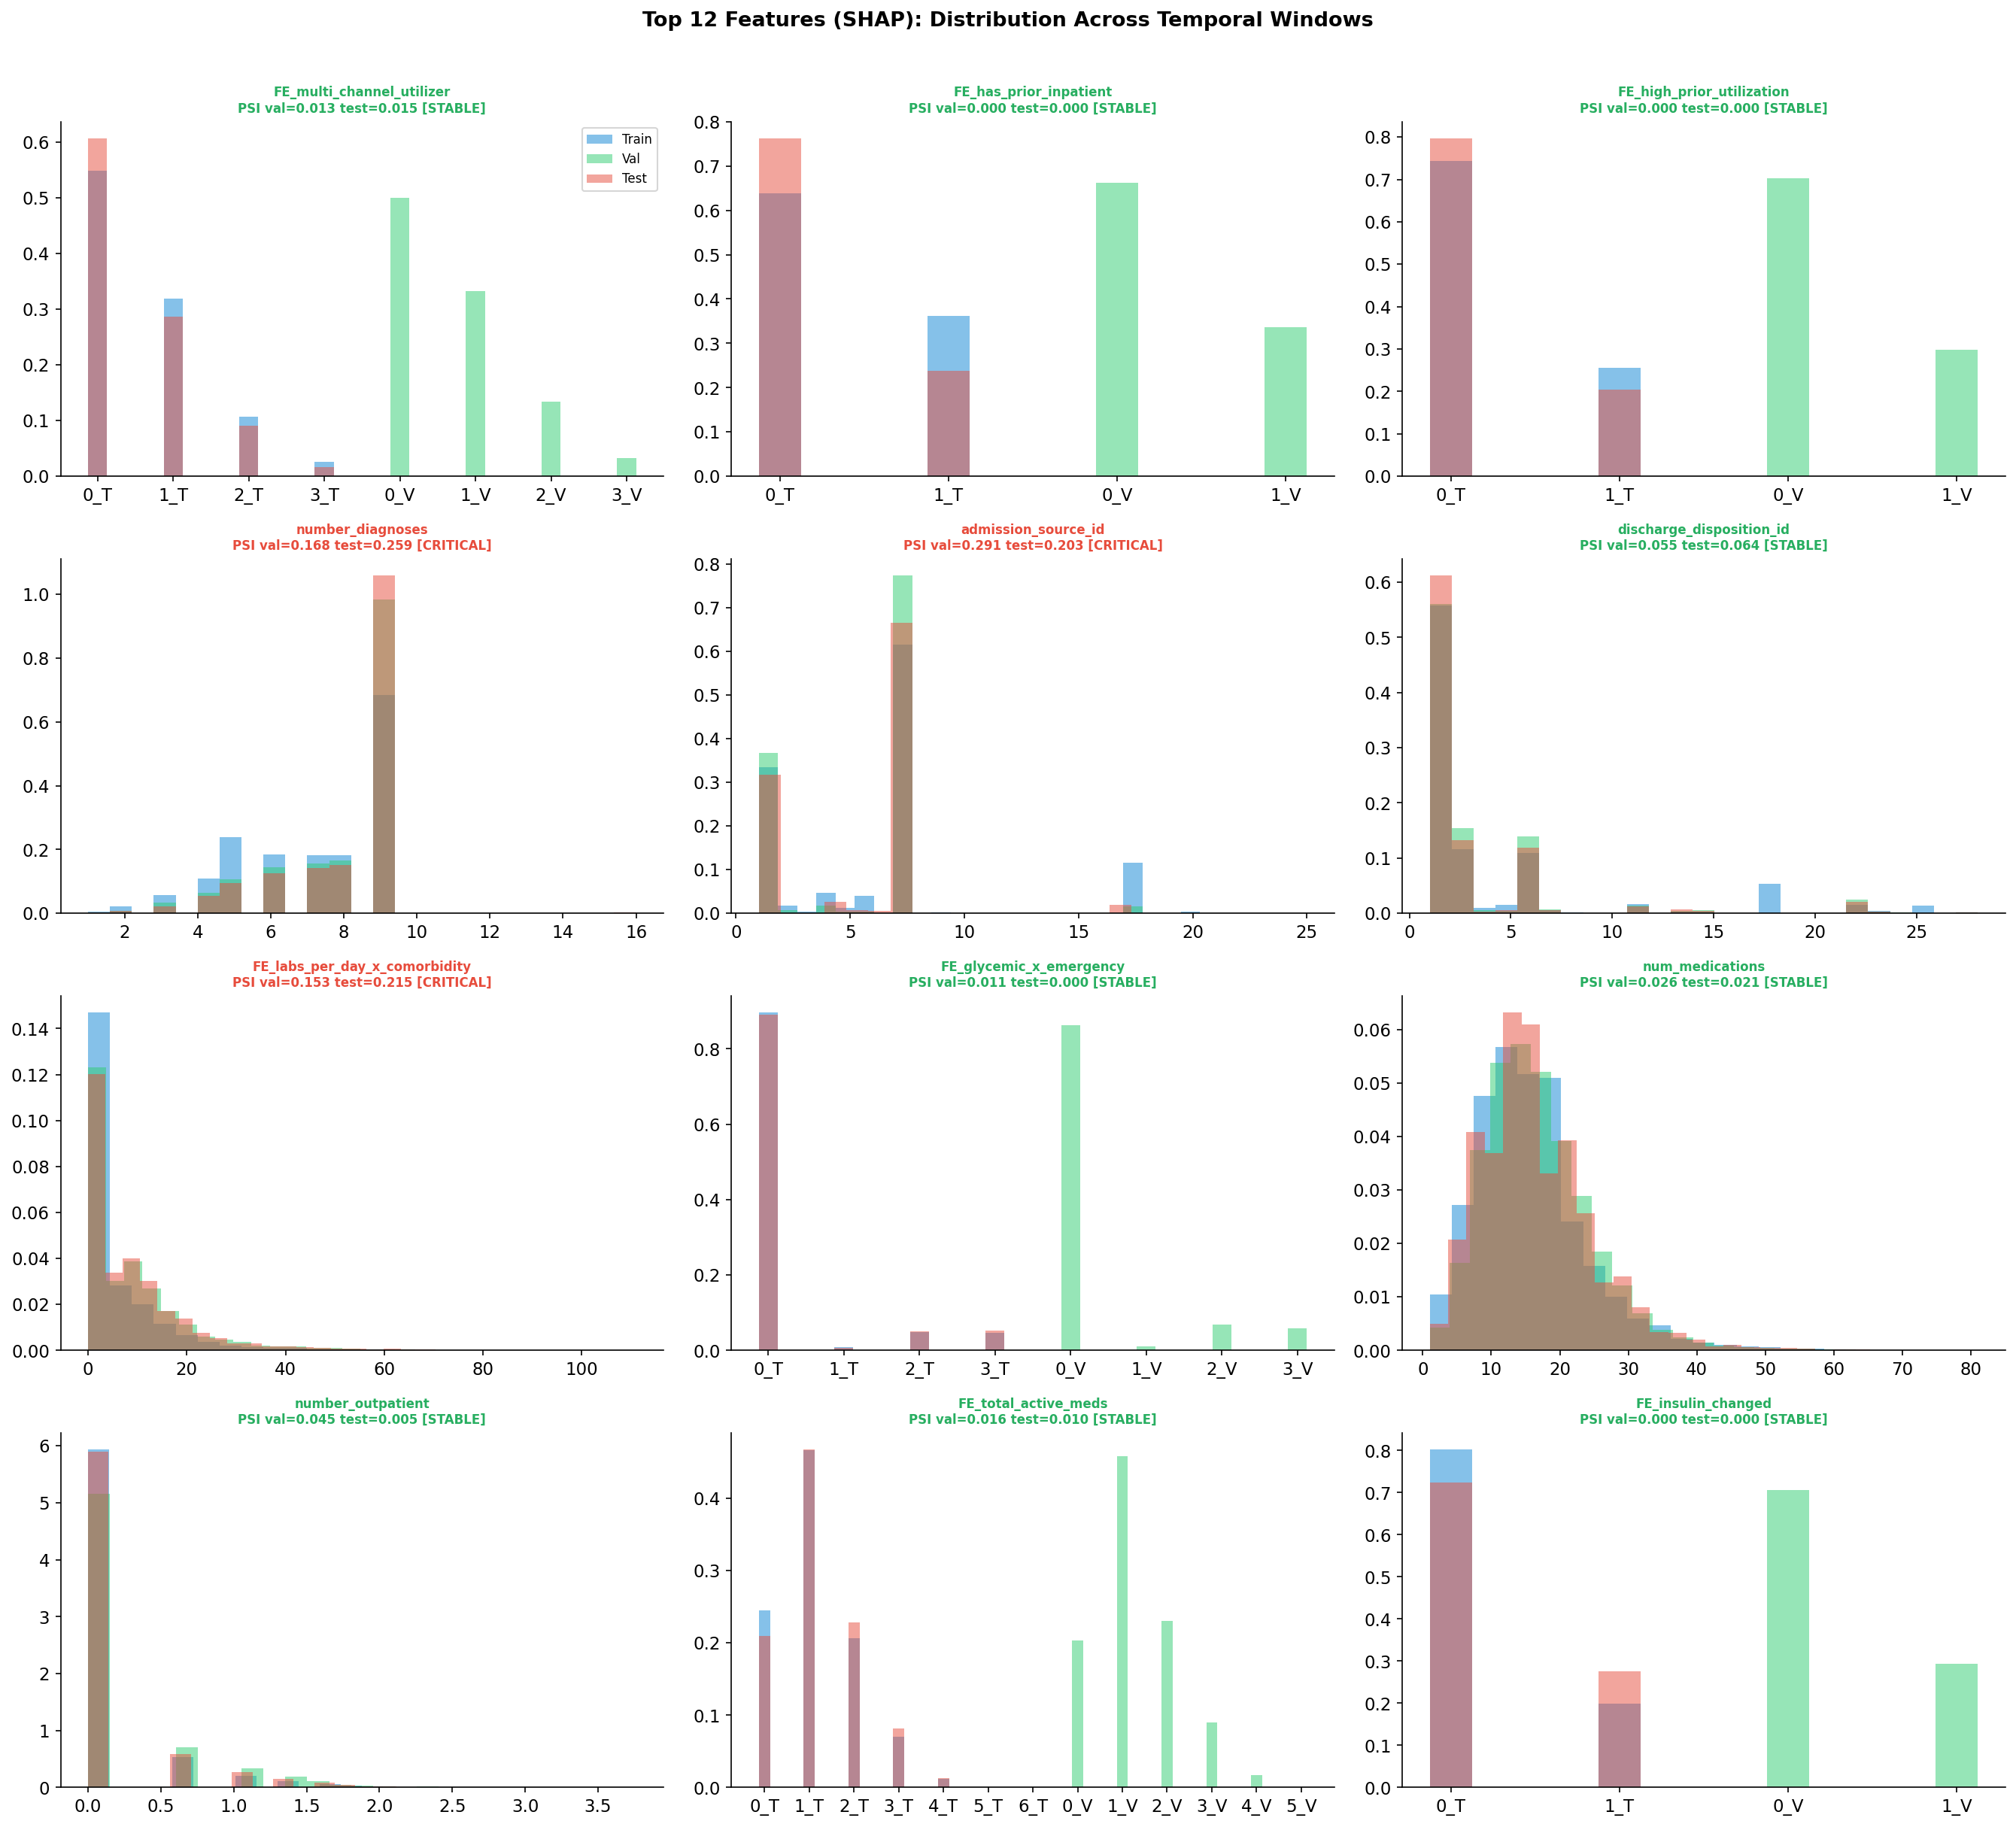

Saved: 18_top12_feature_distributions.png


In [10]:
top12 = mean_shap.head(12)["feature"].tolist()

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, feat in enumerate(top12):
    ax = axes[i]
    for name, df, color, alpha in [
        ("Train", train, '#3498db', 0.6),
        ("Val",   val,   '#2ecc71', 0.5),
        ("Test",  test,  '#e74c3c', 0.5)
    ]:
        data = df[feat].dropna()
        if data.nunique() <= 10:
            vc = data.value_counts(normalize=True).sort_index()
            ax.bar([str(x) + f'_{name[0]}' for x in vc.index],
                   vc.values, alpha=alpha, label=name, color=color, width=0.25)
        else:
            ax.hist(data, bins=25, alpha=alpha, label=name,
                    color=color, density=True, edgecolor='none')

    psi_v = psi(train[feat].values, val[feat].values)
    psi_t = psi(train[feat].values, test[feat].values)
    status = "CRITICAL" if max(psi_v, psi_t) > 0.20 else \
             "MODERATE" if max(psi_v, psi_t) > 0.10 else "STABLE"
    color_title = '#e74c3c' if status == "CRITICAL" else \
                  '#f39c12' if status == "MODERATE" else '#27ae60'

    ax.set_title(f'{feat}\nPSI val={psi_v:.3f} test={psi_t:.3f} [{status}]',
                 fontsize=8, fontweight='bold', color=color_title)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Top 12 Features (SHAP): Distribution Across Temporal Windows',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "18_top12_feature_distributions.png", bbox_inches='tight')
plt.show()
print("Saved: 18_top12_feature_distributions.png")

## 9. Engineered Feature (FE_) Audit
29 FE_ features selected. Validates that engineered features add information
beyond raw features. Compares FE_ vs raw MI scores and SHAP scores.

=== FE_ Feature Audit ===

FE_ features selected   : 29
Raw features selected    : 24

FE_ MI mean  : 0.006504
Raw MI mean  : 0.005835

FE_ SHAP mean: 0.005606
Raw SHAP mean: 0.003583


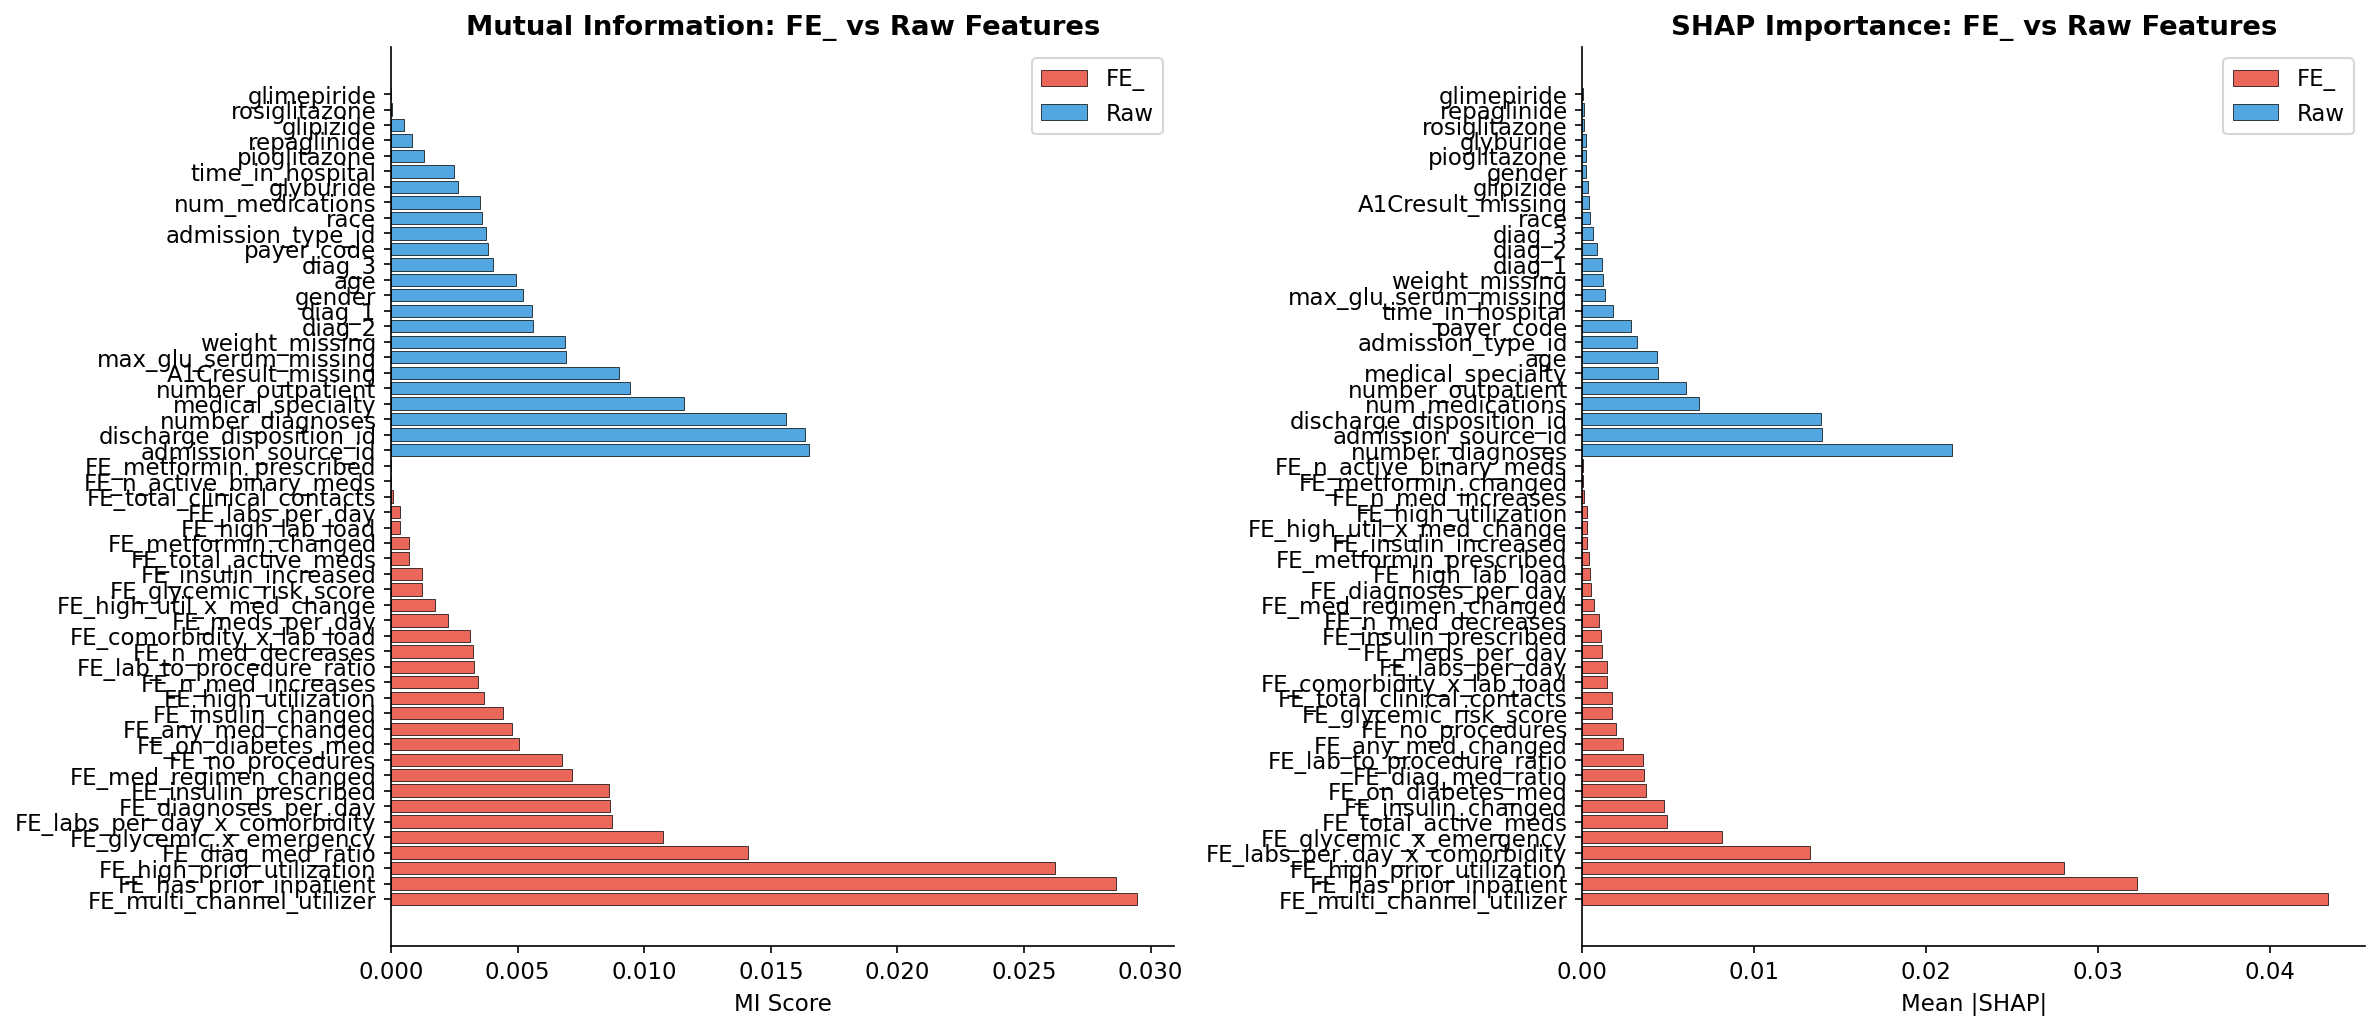

Saved: 19_fe_vs_raw_importance.png


In [11]:
fe_mi   = mi_df[mi_df['is_fe']].copy()
raw_mi  = mi_df[~mi_df['is_fe']].copy()

print("=== FE_ Feature Audit ===")
print(f"\nFE_ features selected   : {len(fe_mi)}")
print(f"Raw features selected    : {len(raw_mi)}")
print(f"\nFE_ MI mean  : {fe_mi['mi_score'].mean():.6f}")
print(f"Raw MI mean  : {raw_mi['mi_score'].mean():.6f}")

fe_shap  = mean_shap[mean_shap['is_fe']]
raw_shap = mean_shap[~mean_shap['is_fe']]
print(f"\nFE_ SHAP mean: {fe_shap['shap_mean'].mean():.6f}")
print(f"Raw SHAP mean: {raw_shap['shap_mean'].mean():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# MI comparison
axes[0].barh(fe_mi['feature'], fe_mi['mi_score'],
             color='#e74c3c', alpha=0.85, label='FE_', edgecolor='black', linewidth=0.4)
axes[0].barh(raw_mi['feature'], raw_mi['mi_score'],
             color='#3498db', alpha=0.85, label='Raw', edgecolor='black', linewidth=0.4)
axes[0].set_xlabel('MI Score')
axes[0].set_title('Mutual Information: FE_ vs Raw Features', fontweight='bold')
axes[0].legend()

# SHAP comparison
axes[1].barh(fe_shap['feature'], fe_shap['shap_mean'],
             color='#e74c3c', alpha=0.85, label='FE_', edgecolor='black', linewidth=0.4)
axes[1].barh(raw_shap['feature'], raw_shap['shap_mean'],
             color='#3498db', alpha=0.85, label='Raw', edgecolor='black', linewidth=0.4)
axes[1].set_xlabel('Mean |SHAP|')
axes[1].set_title('SHAP Importance: FE_ vs Raw Features', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURE_DIR / "19_fe_vs_raw_importance.png", bbox_inches='tight')
plt.show()
print("Saved: 19_fe_vs_raw_importance.png")

## 10. Post-Pipeline Null Audit
Confirms no nulls in processed features across all three splits.
Any null in model input would cause silent failures during training.

In [12]:
print("=== Post-Pipeline Null Audit ===\n")
all_clean = True
for name, df in [("train", train), ("val", val), ("test", test)]:
    null_counts = df[FEAT_COLS].isna().sum()
    null_cols   = null_counts[null_counts > 0]
    if null_cols.empty:
        print(f"[PASS] {name} — all {len(FEAT_COLS)} feature columns null-free")
    else:
        all_clean = False
        print(f"[FAIL] {name} — {len(null_cols)} columns with nulls:")
        print(null_cols.to_string())

print(f"\nNull audit result: {'CLEAN — safe to proceed to modeling' if all_clean else 'ISSUES FOUND — review before modeling'}")

=== Post-Pipeline Null Audit ===

[PASS] train — all 53 feature columns null-free
[PASS] val — all 53 feature columns null-free
[PASS] test — all 53 feature columns null-free

Null audit result: CLEAN — safe to proceed to modeling


## 11. Preprocessing Audit Summary
Consolidated findings ready for modeling stage.

In [13]:
critical_psi = (psi_df['max_psi'] > 0.20).sum()
moderate_psi = ((psi_df['max_psi'] > 0.10) & (psi_df['max_psi'] <= 0.20)).sum()
stable_psi   = (psi_df['max_psi'] < 0.10).sum()

top1_mi   = mi_df.iloc[0]['feature']
top1_shap = mean_shap.iloc[0]['feature']

print("=" * 65)
print("PREPROCESSING AUDIT SUMMARY — DriftSentinel")
print("=" * 65)
print(f"  Train/Val/Test rows          : {len(train):,} / {len(val):,} / {len(test):,}")
print(f"  Selected features            : {len(FEAT_COLS)} (FE_={len(FE_COLS)}, raw={len(RAW_COLS)})")
print(f"  Data leakage                 : NONE — row duplicates=0, |r|<0.80")
print(f"  Post-pipeline nulls          : NONE across all splits")
print(f"  PSI critical (>0.20)         : {critical_psi} features — drift simulation confirmed")
print(f"  PSI moderate (0.10-0.20)     : {moderate_psi} features")
print(f"  PSI stable   (<0.10)         : {stable_psi} features")
print(f"  Top MI feature               : {top1_mi}")
print(f"  Top SHAP feature             : {top1_shap}")
print(f"  MI vs SHAP Spearman rho      : {rho:.4f}")
print(f"  Concept drift evidence       : test NO rate = 66.4% vs train 51.0%")
print("=" * 65)
print(f"\nFigures saved to: {FIGURE_DIR}")
print("Ready for: 03_model_training.ipynb")

PREPROCESSING AUDIT SUMMARY — DriftSentinel
  Train/Val/Test rows          : 63,492 / 20,949 / 17,325
  Selected features            : 53 (FE_=29, raw=24)
  Data leakage                 : NONE — row duplicates=0, |r|<0.80
  Post-pipeline nulls          : NONE across all splits
  PSI critical (>0.20)         : 5 features — drift simulation confirmed
  PSI moderate (0.10-0.20)     : 2 features
  PSI stable   (<0.10)         : 46 features
  Top MI feature               : FE_multi_channel_utilizer
  Top SHAP feature             : FE_multi_channel_utilizer
  MI vs SHAP Spearman rho      : 0.6537
  Concept drift evidence       : test NO rate = 66.4% vs train 51.0%

Figures saved to: C:\Users\sharg\Desktop\github\DriftSentinel\outputs\figure
Ready for: 03_model_training.ipynb
